# DOMINANT and raw-text node representations with t-SNE

This notebook creates two 2x3 t-SNE figures for all datasets. The first uses the final shared-GNN representation from each best-AUC DOMINANT checkpoint. The second uses the raw 768-dimensional SBERT text representation, before degree features or graph-message passing.

Yellow points are IoT nodes (label=True); blue points are control nodes (label=False).

In [4]:
from pathlib import Path
import gc
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch_geometric.nn import GCN
from pygod.detector.dominant import DOMINANTBase

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from dominant import load_data  # noqa: E402

DATASETS = sorted(path.name for path in (ROOT / 'data').iterdir() if path.is_dir())
CHECKPOINT_ROOT = ROOT / 'artifacts/results/benchmark/saved_models_best_auc'
TSNE_SEED = 42
# Leave this False while other GPU experiments are running.
USE_GPU_FOR_DOMINANT = True
DEVICE = torch.device('cuda' if USE_GPU_FOR_DOMINANT and torch.cuda.is_available() else 'cpu')
print(f'datasets={DATASETS}; DOMINANT encoder device={DEVICE}; t-SNE device=CPU')

datasets=['UAE', 'china', 'cuba', 'iran', 'russia', 'venezuela']; DOMINANT encoder device=cuda; t-SNE device=CPU


In [5]:
def project(values):
    # Keep one contiguous float32 input; do not perform PCA preprocessing or PCA initialization.
    values = np.asarray(values, dtype=np.float32, order='C')
    perplexity = min(30, max(2, (len(values) - 1) // 3))
    projection = TSNE(
        n_components=2, perplexity=perplexity, init='random',
        learning_rate='auto', random_state=TSNE_SEED,
        method='barnes_hut', angle=0.5, n_jobs=1,
    ).fit_transform(values)
    return projection, perplexity


def plot_grid(loader, title):
    fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
    handles = None
    for axis, dataset in zip(axes.flat, DATASETS):
        values, labels = loader(dataset)
        xy, perplexity = project(values)
        control = axis.scatter(xy[~labels, 0], xy[~labels, 1], c='#1f77b4',
            label='Control (label=False)', s=8, alpha=0.7, linewidths=0)
        iot = axis.scatter(xy[labels, 0], xy[labels, 1], c='#FFD700',
            edgecolors='#8a6d00', label='IoT (label=True)', s=12, alpha=0.9, linewidths=0.2)
        axis.set_title(f'{dataset} (n={len(labels):,}; perplexity={perplexity})')
        axis.set_xlabel('t-SNE component 1')
        axis.set_ylabel('t-SNE component 2')
        axis.grid(alpha=0.2)
        handles = (control, iot)
        # The scatter artists retain only the 2-D coordinates.
        del values, labels, xy
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()
    fig.suptitle(title, fontsize=16)
    fig.legend(handles, [h.get_label() for h in handles], loc='upper center',
               ncol=2, frameon=True, bbox_to_anchor=(0.5, 0.96))
    plt.show()

DOMINANT UAE: (9391, 64); IoT=3,349
DOMINANT china: (23028, 64); IoT=768
DOMINANT cuba: (20247, 64); IoT=461
DOMINANT iran: (14486, 64); IoT=4,659
DOMINANT russia: (716, 64); IoT=275
DOMINANT venezuela: (5021, 64); IoT=533


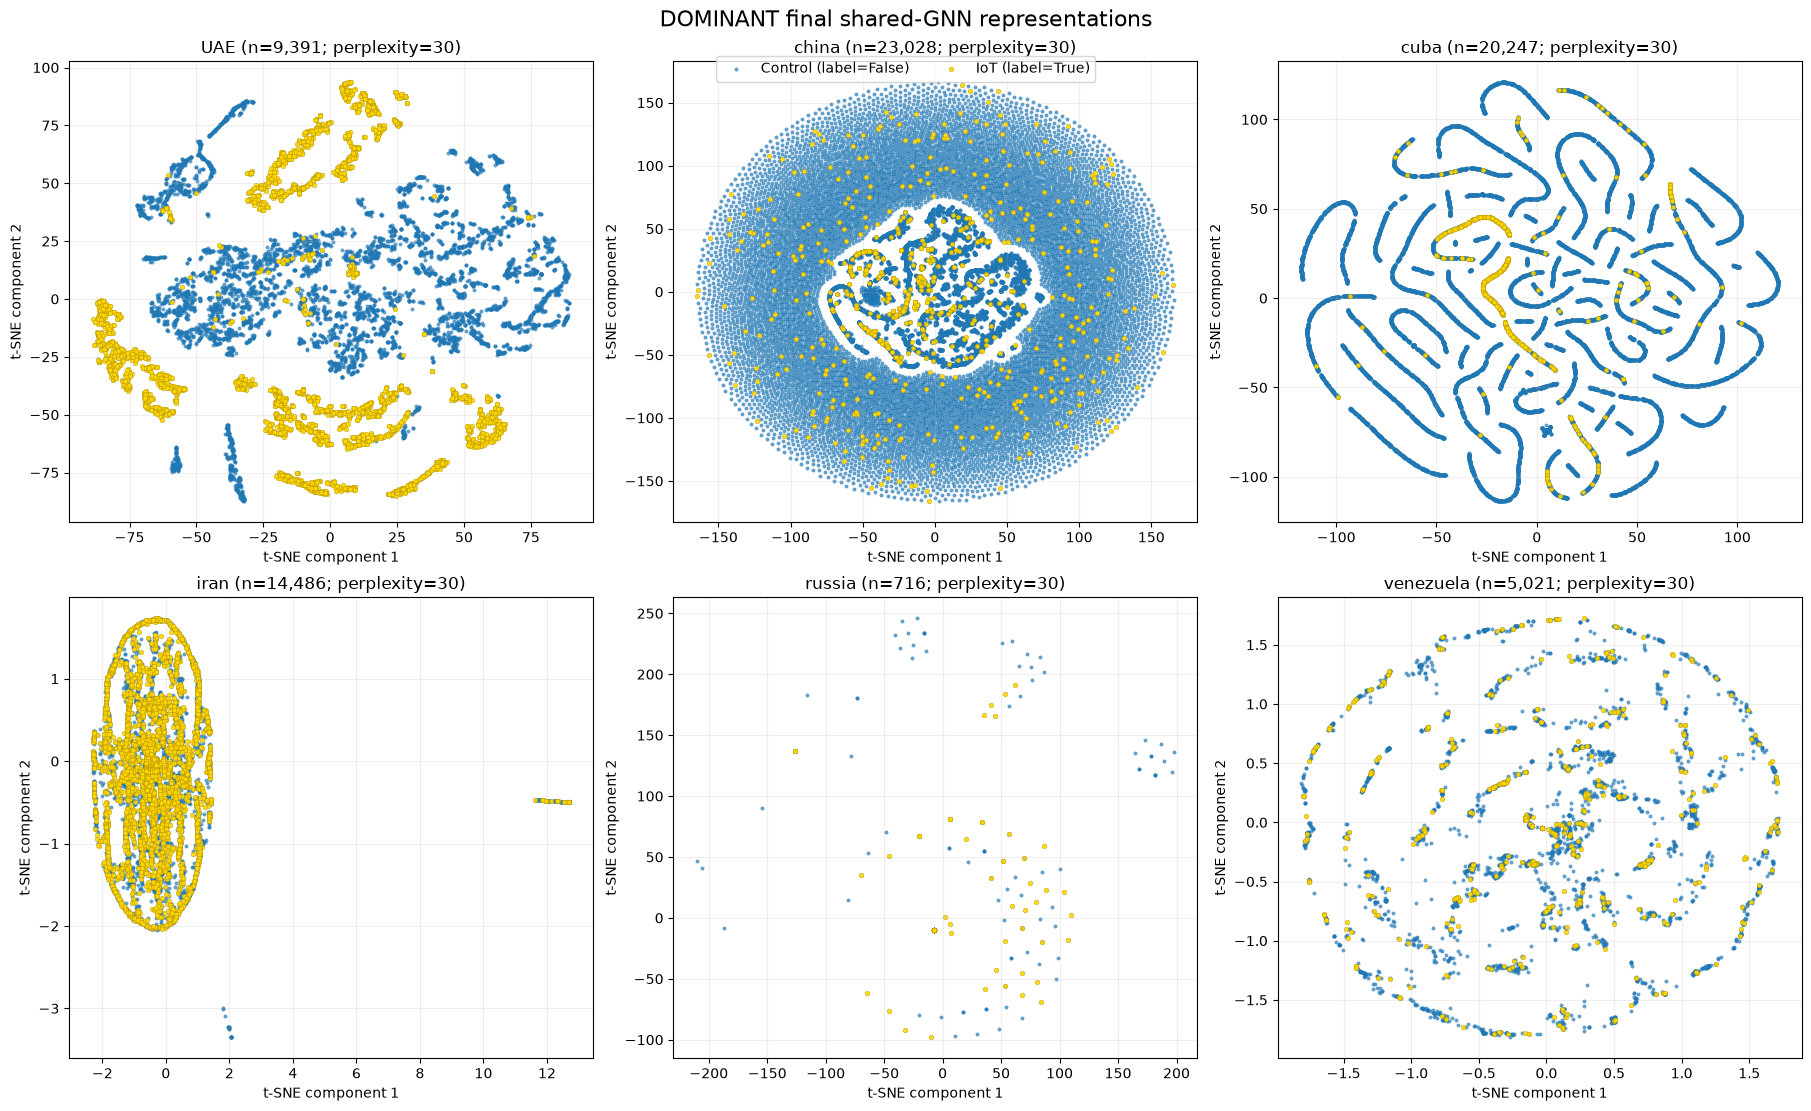

In [6]:
def load_dominant_representation(dataset):
    _, data = load_data(dataset)
    checkpoint = torch.load(CHECKPOINT_ROOT / dataset / 'pygod_dominant/model.pt',
                            map_location='cpu', weights_only=False)
    hp = checkpoint['hyperparameters']
    encoder = DOMINANTBase(in_dim=data.num_features, hid_dim=int(hp['hid_dim']),
        num_layers=int(hp.get('num_layers', 4)), dropout=0.0, act=F.relu,
        sigmoid_s=False, backbone=GCN).to(DEVICE)
    encoder.load_state_dict(checkpoint['state_dict'])
    encoder.eval()
    features = data.x.to(DEVICE)
    edge_index = data.edge_index.to(DEVICE)
    with torch.inference_mode():
        values = encoder.shared_encoder(features, edge_index).cpu().numpy()
    labels = data.y.cpu().numpy().astype(bool)
    print(f'DOMINANT {dataset}: {values.shape}; IoT={labels.sum():,}')
    del checkpoint, encoder, features, edge_index, data
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return values, labels


plot_grid(load_dominant_representation, 'DOMINANT final shared-GNN representations')

Raw text UAE: (9391, 768); IoT=3,349
Raw text china: (23028, 768); IoT=768
Raw text cuba: (20247, 768); IoT=461
Raw text iran: (14486, 768); IoT=4,659
Raw text russia: (716, 768); IoT=275
Raw text venezuela: (5021, 768); IoT=533


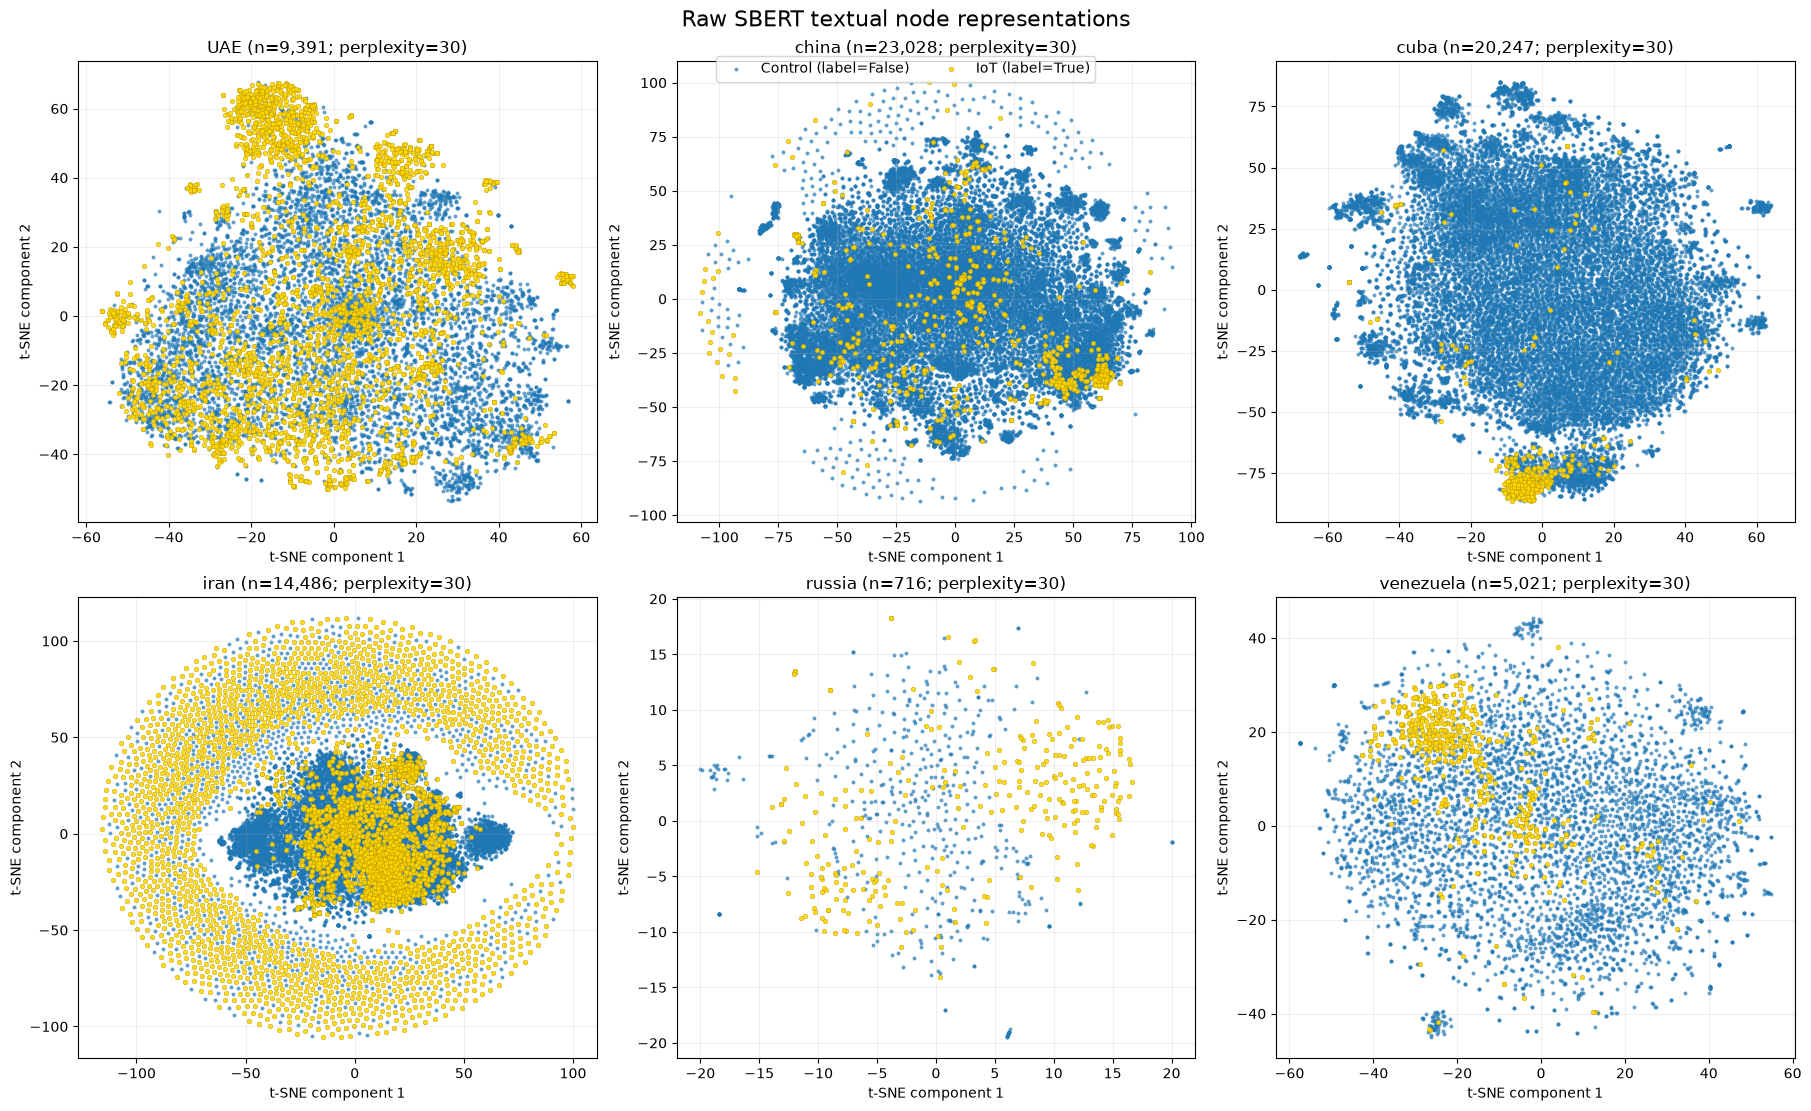

In [7]:
def load_raw_text_representation(dataset):
    # Avoid load_data(): the raw-text plot does not need edge_index or degree features.
    dataset_root = ROOT / 'data' / dataset
    values = torch.load(dataset_root / 'sbert_nodeattributes_mostPop5.pt',
                        map_location='cpu', weights_only=True).numpy()
    with (dataset_root / '0.7_datasets.pkl').open('rb') as file:
        labels = np.asarray(pickle.load(file)['labels'], dtype=bool)
    assert len(values) == len(labels), f'Unaligned text embeddings for {dataset}'
    print(f'Raw text {dataset}: {values.shape}; IoT={labels.sum():,}')
    return values, labels


plot_grid(load_raw_text_representation, 'Raw SBERT textual node representations')

## Interpretation note

Each panel is fit independently. Axes, orientation, distances, and apparent cluster sizes are therefore not comparable across datasets or between figures. t-SNE is exploratory visualization, not quantitative evidence of separability.